# Flow Matching: ECG Dataset
Author: diego.camarero@estudiante.uam.es

In [1]:
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 40.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [2]:
experiment_number = '01'

kernel_sizes = (9, 9, 9, 9)

dataset_size = 9246
n_points = 500

epoch_to_load = 500

experiment_name = f"training_flow_{experiment_number}_ECG"

In [3]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/notebooks

[INFO] Running on device: cuda



In [4]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [5]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

# Project modules
import flow.flow_process as flow

from models.v_model import UNetScoreModel

from data.ecg_dataset import (
    load_ecg_data,
)

from utils.metrics import (
    compute_dataset_metrics,
    full_report,
    checkpoint_summary,
    plot_training_evolution,
    plot_loss_history,
)

from utils.checkpoints import (
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_flow_process,
)

In [6]:
from pathlib import Path
from datetime import datetime

RESULTS_DATA_DIR = Path("../../results/data")
RESULTS_DATA_DIR.mkdir(parents=True, exist_ok=True)

def save_tensor_bundle(filename, **kwargs):
    payload = {"timestamp": datetime.now().isoformat()}
    for k, v in kwargs.items():
        payload[k] = v.detach().cpu() if torch.is_tensor(v) else v

    path = RESULTS_DATA_DIR / filename
    torch.save(payload, path)
    size_mb = path.stat().st_size / 1e6
    print(f"Saved -> {path}  ({size_mb:.2f} MB)")
    return path

## Dataset creation

In [7]:
from data.ecg_dataset import apply_bandpass_filter

LEAD = 1
SAMPLING_RATE = 100 # or 500
MAX_SAMPLES = 9246
DATASET_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/ECG dataset/'

CACHE_PATH = DATASET_PATH + f'cache_lead{LEAD}_sr{SAMPLING_RATE}_n{MAX_SAMPLES}.pt'

print("Loading from cache...")
checkpoint = torch.load(CACHE_PATH)
data_train = checkpoint['data'][:dataset_size, :, :n_points]
data_train = apply_bandpass_filter(data_train, SAMPLING_RATE)
print(f"Dataset shape: {data_train.shape}")

# For later metrics comparison
real_metrics_df = compute_dataset_metrics(data_train, fs=SAMPLING_RATE)
real_ok_df = real_metrics_df[real_metrics_df['success']]

# Normalize dataset
data_mean = data_train.mean()
data_std = data_train.std()
data_eps = 1e-8
data_train_norm = (data_train - data_mean) / (data_std + data_eps)

Loading from cache...
Dataset shape: torch.Size([9246, 1, 500])


torch.Size([8, 1, 500])


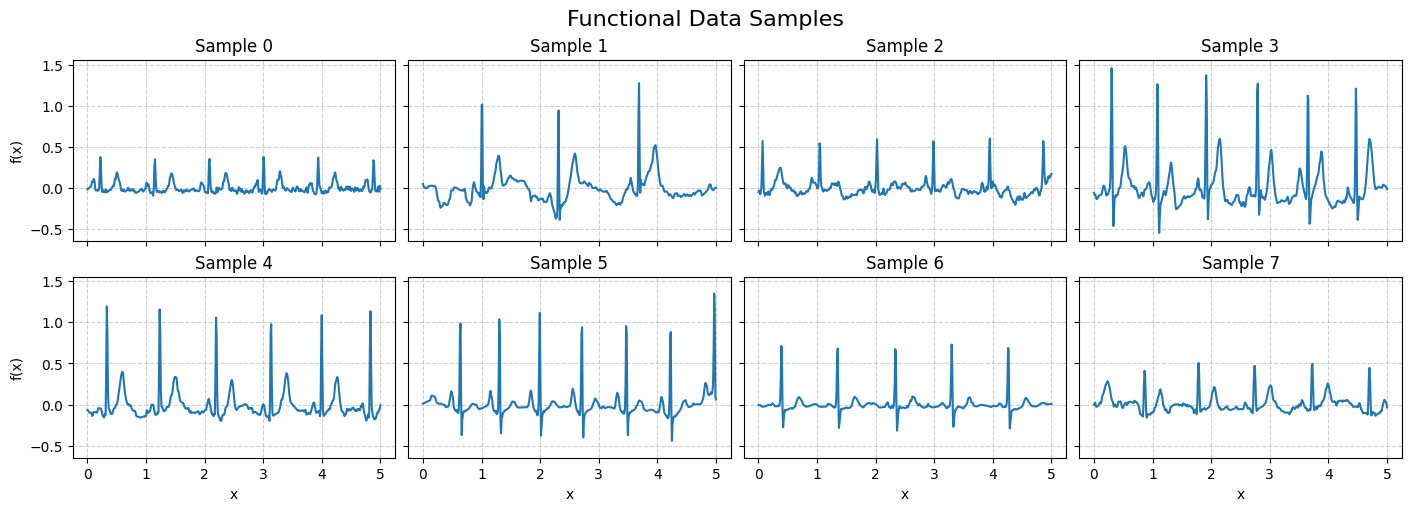

In [8]:
# Create functional dataset

N, _, M = data_train.shape
x_inf, x_sup = 0.0, 5.0
axis_x = torch.linspace(x_inf, x_sup, M)

# Plot some examples of the dataset

n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x=axis_x,
)

In [9]:
# save training dataset
save_tensor_bundle(
    "dataset_samples.pt",
    data=data_train,
    data_eps=data_eps,
    seed=seed,
    x_inf=x_inf,
    x_sup=x_sup,
    sampling_rate=SAMPLING_RATE,
)

Saved -> ../../results/data/dataset_samples.pt  (18.49 MB)


PosixPath('../../results/data/dataset_samples.pt')

## Flow Matching process

In [10]:
def alpha_t(t):
    return 1 - t

def diff_alpha_t(t):
    return -1

def beta_t(t):
    return t

def diff_beta_t(t):
    return 1

t_0 = 0.0
T = 1.0
t_eps = 0.0
flow_process = flow.FlowMatchingProcess(
    alpha_t=alpha_t,
    beta_t=beta_t,
    diff_alpha_t=diff_alpha_t,
    diff_beta_t=diff_beta_t,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([9246, 100, 1, 500])


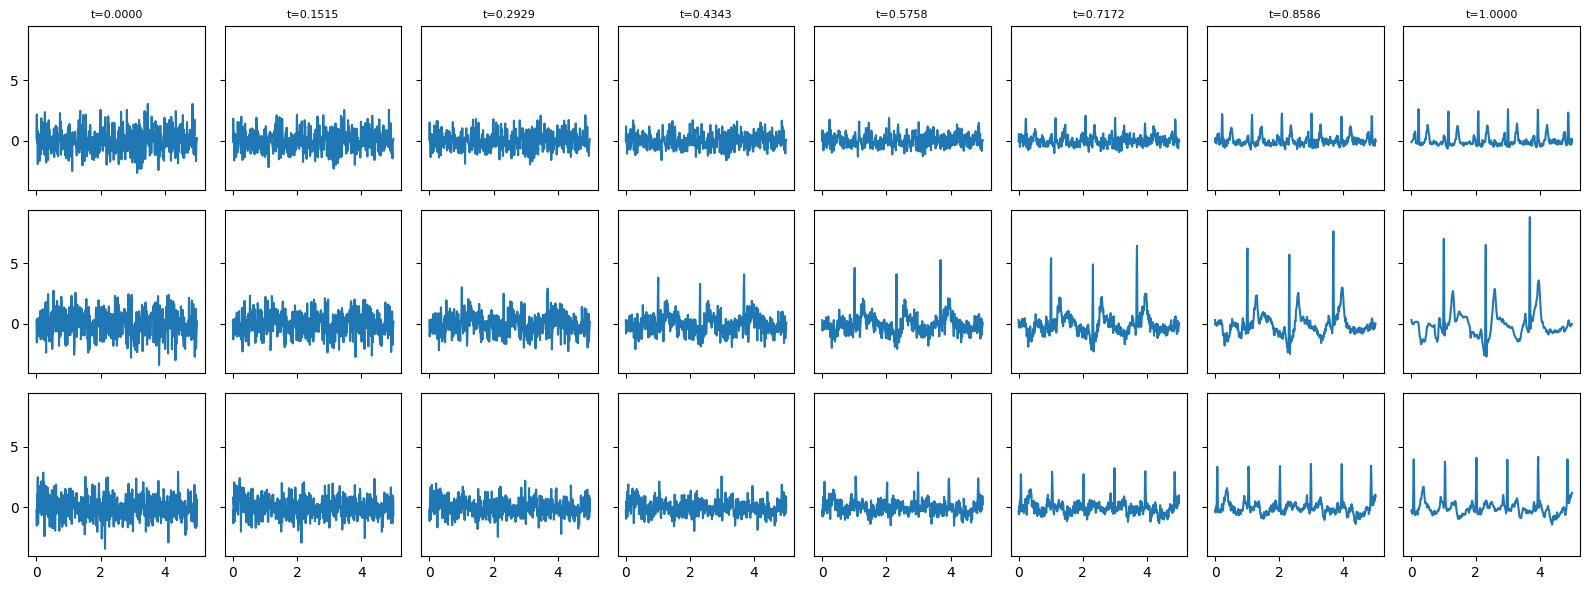

In [11]:
# Example flow process

n_steps = 100

synthetic_functions_t = flow.flow_interpolation(data_train_norm[:].to(device), alpha_t, beta_t, t_0, T, n_steps)
print(synthetic_functions_t.shape)

plot_flow_process(
    synthetic_functions_t,
    axis_x=axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

In [12]:
# Save flow forward interpolation path
save_tensor_bundle(
    "forward_flow_interpolation.pt",
    data=synthetic_functions_t,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

Saved -> ../../results/data/forward_flow_interpolation.pt  (1849.20 MB)


PosixPath('../../results/data/forward_flow_interpolation.pt')

## Synthetic data generation

In [13]:
# Define the model

v_model = UNetScoreModel(
    multiply_inv_sigma=None,
    kernel_sizes=kernel_sizes,
    random_state=seed,
    device=device,
)

learning_rate = 1.0e-3
optimizer = Adam(v_model.parameters(), lr=learning_rate)

In [14]:
# Compute results

checkpoint_path = os.path.join(
    CHECKPOINTS_DIR,
    experiment_name,
    f"checkpoint_epoch_{epoch_to_load}.pth"
)

def ode(x_t, t, v_model):
    v = v_model(x_t, t)
    return v

n_functions = 9246
torch.manual_seed(seed)
x_0 = torch.randn(n_functions, 1, M, device=device)

n_steps = 100
t_0 = 0.0

v_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(checkpoint_path, v_model, optimizer)
v_model.eval()

torch.manual_seed(seed)

with torch.no_grad():
    times, synthetic_functions_t = flow.euler_integrator(
        x_initial=x_0,
        t_start=t_0,
        t_end=T,
        n_times=n_steps,
        ode_coefficient=partial(ode, v_model=v_model)
    )

print(synthetic_functions_t.shape)

synthetic_functions_norm = synthetic_functions_t[:, -1, :, :]

synthetic_functions = (synthetic_functions_norm * (data_std + data_eps) + data_mean)

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Flow matching/checkpoints/training_flow_01_ECG/checkpoint_epoch_500.pth
Epoch: 500. Loss: 244.386578. Time: 33:47
torch.Size([9246, 100, 1, 500])


In [15]:
# Save generated samples
save_tensor_bundle(
    "generated_flow_samples.pt",
    data=synthetic_functions_t,
    seed=seed,
)

Saved -> ../../results/data/generated_flow_samples.pt  (1849.20 MB)


PosixPath('../../results/data/generated_flow_samples.pt')

## Results

In [16]:
print("Epoch:", epoch)
print("Loss:", loss)

Epoch: 500
Loss: 244.3865775657685


R-peak detection success rate — real: 93.1%, generated: 93.7%


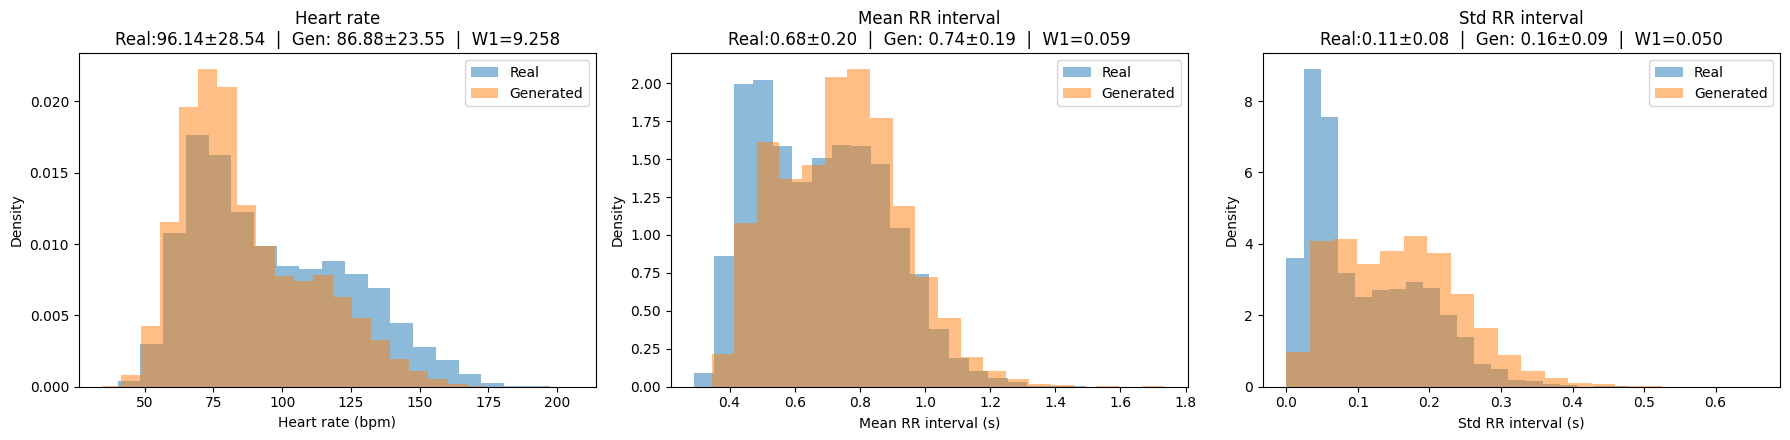

In [17]:
real_metrics_df = compute_dataset_metrics(data_train, fs=SAMPLING_RATE)
gen_metrics_df = compute_dataset_metrics(synthetic_functions, fs=SAMPLING_RATE)
report = full_report(real_metrics_df, gen_metrics_df)

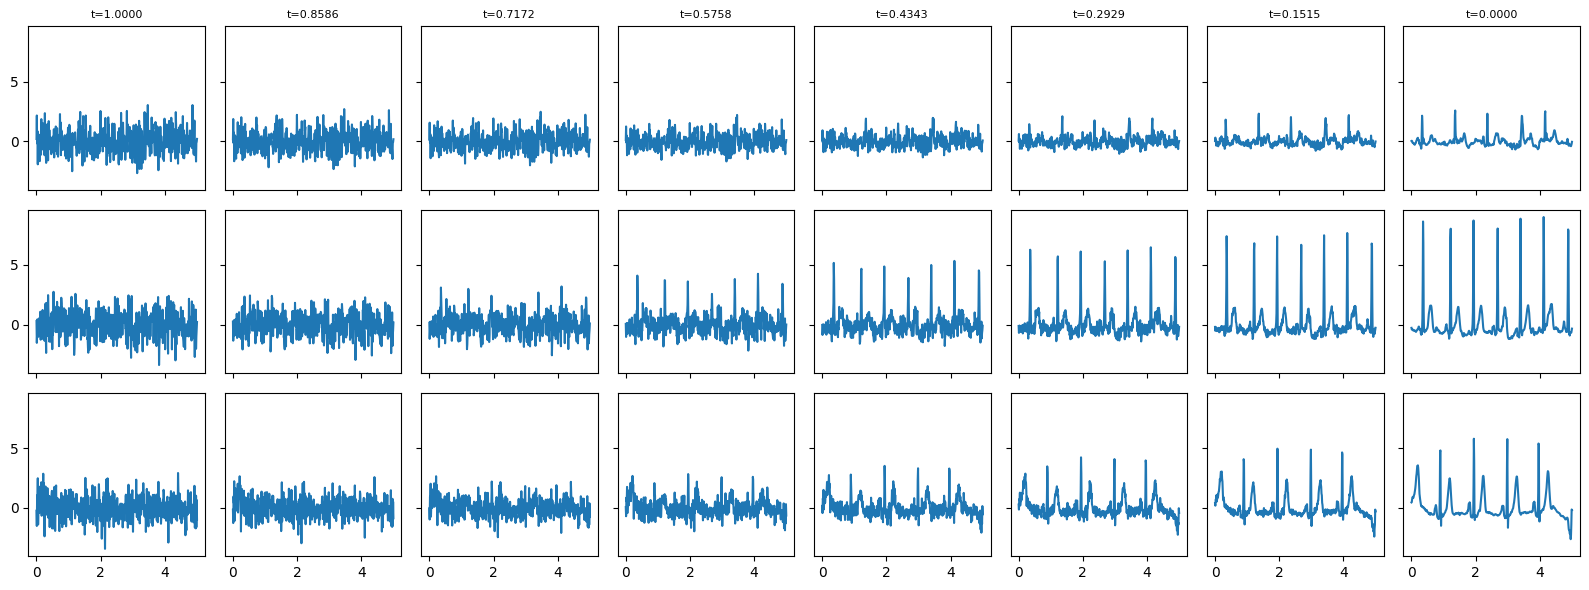

In [18]:
plot_flow_process(
    synthetic_functions_t,
    axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_0,
)

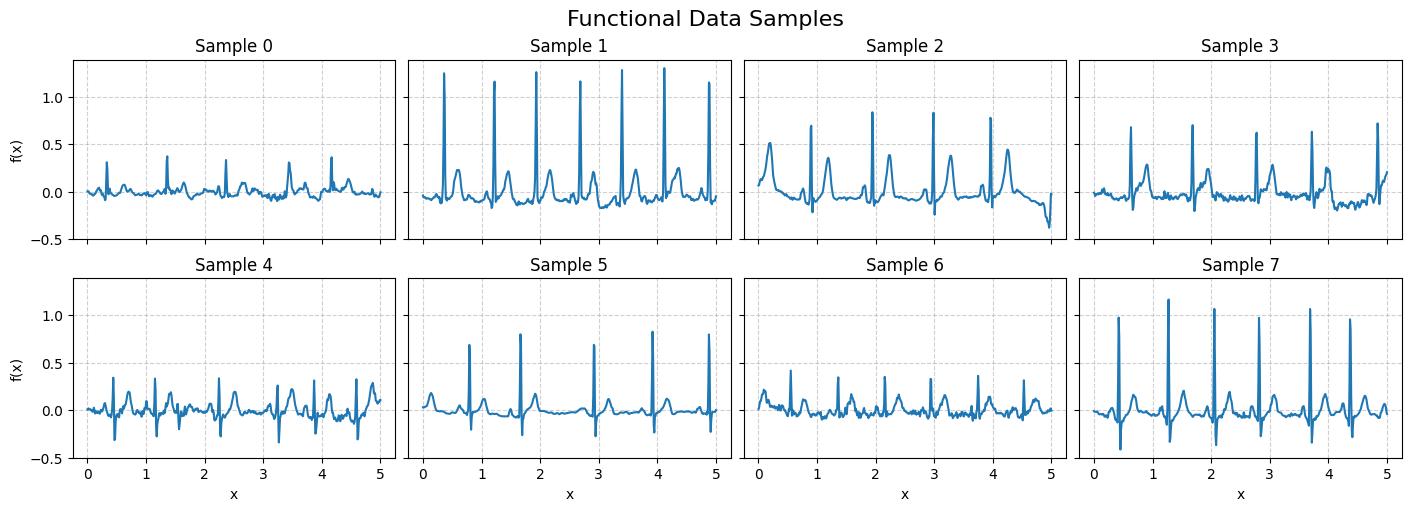

In [19]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x=axis_x,
)